In [1]:
%pip install neurokit2

  Using cached neurokit2-0.2.13-py3-none-any.whl.metadata (27 kB)
Using cached neurokit2-0.2.13-py3-none-any.whl (688 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.6 MB/s  0:00:00m 3.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 9.6 MB/s  0:00:00m 9.5 MB/s eta 0:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1━━━━━━ 0/3 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [neurokit2]━━━━━━━━ 2/3 [neurokit2]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import neurokit2 as nk
print(nk.__version__)

0.2.13


In [3]:
from pathlib import Path
import wfdb
import numpy as np
import matplotlib.pyplot as plt

header_files = list(Path("data").rglob("*.hea"))

print("Number of ECG records found:", len(header_files))
print("First record:", header_files[0])

Number of ECG records found: 1631
First record: data/samitrop_wfdb/313558.hea


In [4]:
record_path = str(header_files[0].with_suffix(""))

record = wfdb.rdrecord(record_path)

print("Sampling frequency:", record.fs)
print("Lead names:", record.sig_name)
print("Signal shape:", record.p_signal.shape)

Sampling frequency: 400
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Signal shape: (4096, 12)


In [5]:
lead_index = record.sig_name.index("II")
ecg_signal = record.p_signal[:, lead_index]

signals, info = nk.ecg_process(
    ecg_signal,
    sampling_rate=record.fs
)

rpeaks = info["ECG_R_Peaks"]

print("Number of R-peaks detected:", len(rpeaks))
print("R-peak sample positions:", rpeaks)

Number of R-peaks detected: 12
R-peak sample positions: [ 220  542  871 1202 1534 1859 2192 2527 2858 3187 3519 3852]


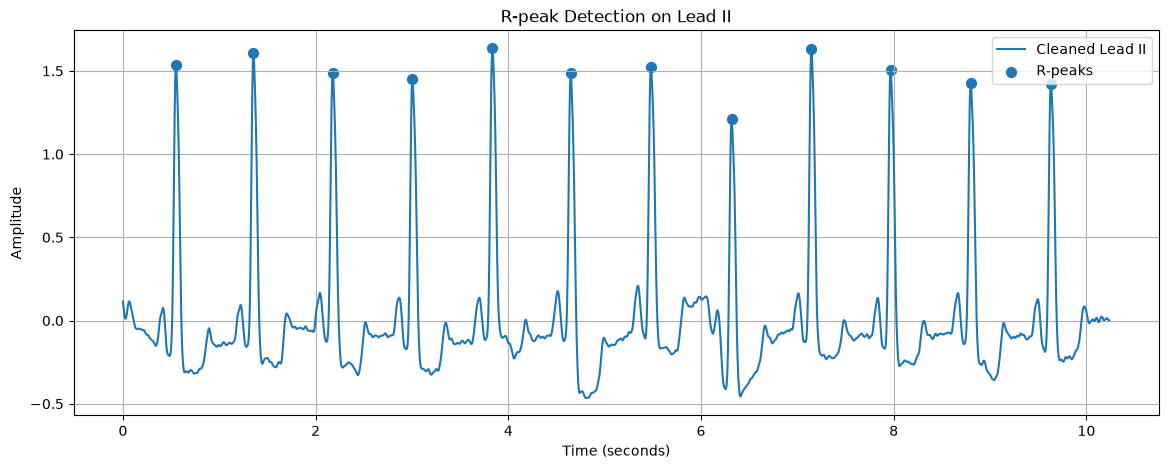

In [6]:
time = np.arange(len(ecg_signal)) / record.fs

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    signals["ECG_Clean"],
    label="Cleaned Lead II"
)

plt.scatter(
    rpeaks / record.fs,
    signals["ECG_Clean"].iloc[rpeaks],
    marker="o",
    s=50,
    label="R-peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("R-peak Detection on Lead II")
plt.legend()
plt.grid()
plt.show()

In [7]:
rr_intervals = np.diff(rpeaks) / record.fs

rr_intervals_ms = rr_intervals * 1000

heart_rate_bpm = 60 / rr_intervals

print("RR intervals (ms):")
print(rr_intervals_ms)

print("\nHeart rate (bpm):")
print(heart_rate_bpm)

print("\nMean heart rate:", np.mean(heart_rate_bpm))

RR intervals (ms):
[805.  822.5 827.5 830.  812.5 832.5 837.5 827.5 822.5 830.  832.5]

Heart rate (bpm):
[74.53416149 72.94832827 72.50755287 72.28915663 73.84615385 72.07207207
 71.64179104 72.50755287 72.94832827 72.28915663 72.07207207]

Mean heart rate: 72.6960296412641


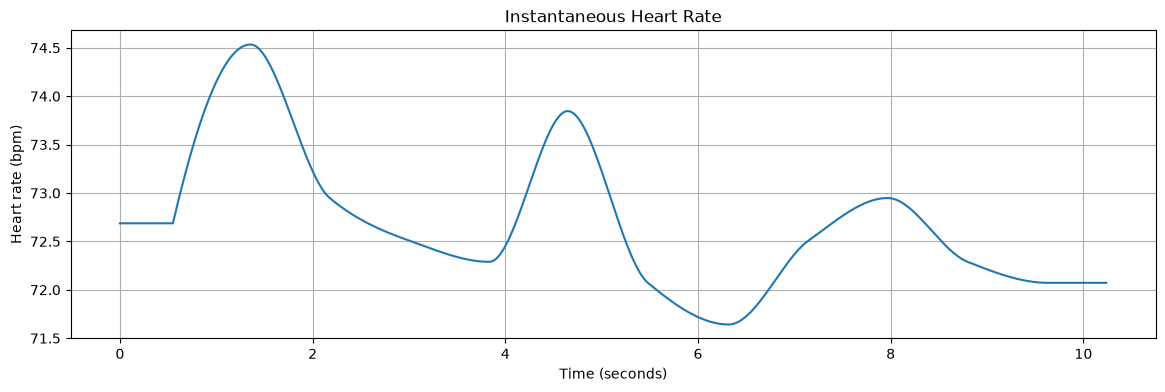

In [8]:
instantaneous_hr = nk.signal_rate(
    rpeaks,
    sampling_rate=record.fs,
    desired_length=len(ecg_signal)
)

plt.figure(figsize=(14, 4))
plt.plot(time, instantaneous_hr)

plt.xlabel("Time (seconds)")
plt.ylabel("Heart rate (bpm)")
plt.title("Instantaneous Heart Rate")
plt.grid()
plt.show()

In [9]:
mean_rr = np.mean(rr_intervals_ms)

sdnn = np.std(
    rr_intervals_ms,
    ddof=1
)

rmssd = np.sqrt(
    np.mean(
        np.diff(rr_intervals_ms) ** 2
    )
)

print("Mean RR:", mean_rr, "ms")
print("SDNN:", sdnn, "ms")
print("RMSSD:", rmssd, "ms")

Mean RR: 825.4545454545455 ms
SDNN: 9.474847084398105 ms
RMSSD: 11.208255885729947 ms


In [10]:
from scipy import signal

cleaned_ecg = signals["ECG_Clean"].to_numpy()
detrended_ecg = signal.detrend(cleaned_ecg)
windowed_ecg = detrended_ecg * np.hanning(len(detrended_ecg))
fft_values = np.fft.rfft(windowed_ecg)
frequencies = np.fft.rfftfreq(len(windowed_ecg),d=1/record.fs)
power = np.abs(fft_values) ** 2

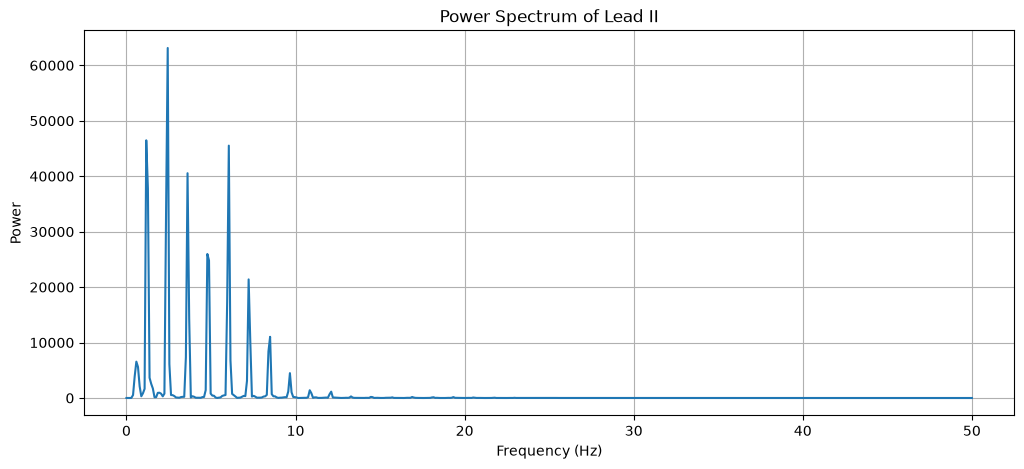

In [11]:
plt.figure(figsize=(12, 5))

mask = frequencies <= 50

plt.plot(frequencies[mask],power[mask])

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectrum of Lead II")
plt.grid()
plt.show()

In [18]:
def extract_ecg_features(ecg_signal, sampling_rate):
    cleaned = nk.ecg_clean(ecg_signal,sampling_rate=sampling_rate)

    _, info = nk.ecg_peaks(cleaned,sampling_rate=sampling_rate)

    rpeaks = info["ECG_R_Peaks"]

    rr_intervals_ms = (np.diff(rpeaks) / sampling_rate) * 1000

    heart_rate = 60000 / rr_intervals_ms

    mean_rr = np.mean(rr_intervals_ms)

    sdnn = np.std(rr_intervals_ms,ddof=1)

    rmssd = np.sqrt(np.mean(np.diff(rr_intervals_ms) ** 2))

    mean_heart_rate = np.mean(heart_rate)

    _, waves = nk.ecg_delineate(
        cleaned,
        rpeaks,
        sampling_rate=sampling_rate,
        method="dwt"
    )

    qrs_durations = []

    r_onsets = waves.get("ECG_R_Onsets", [])
    r_offsets = waves.get("ECG_R_Offsets", [])

    for onset, offset in zip(r_onsets, r_offsets):
        if onset is None or offset is None:
            continue

        if np.isnan(onset) or np.isnan(offset):
            continue

        duration = ((offset - onset) / sampling_rate) * 1000

        if 40 <= duration <= 300:
            qrs_durations.append(duration)

    mean_qrs_duration = (
        np.median(qrs_durations)
        if len(qrs_durations) > 0
        else np.nan
    )

    signal_mean = np.mean(cleaned)
    signal_std = np.std(cleaned)
    signal_max = np.max(cleaned)
    signal_min = np.min(cleaned)

    features = {
        "mean_rr_ms": mean_rr,
        "sdnn_ms": sdnn,
        "rmssd_ms": rmssd,
        "heart_rate_bpm": mean_heart_rate,
        "qrs_duration_ms": mean_qrs_duration,
        "signal_mean": signal_mean,
        "signal_std": signal_std,
        "signal_max": signal_max,
        "signal_min": signal_min
    }

    return features

In [19]:
features = extract_ecg_features(
    ecg_signal,
    record.fs
)

features

{'mean_rr_ms': np.float64(825.4545454545455),
 'sdnn_ms': np.float64(9.474847084398105),
 'rmssd_ms': np.float64(11.208255885729947),
 'heart_rate_bpm': np.float64(72.6960296412641),
 'qrs_duration_ms': np.float64(242.5),
 'signal_mean': np.float64(-0.0009175703984988688),
 'signal_std': np.float64(0.38318269480834627),
 'signal_max': np.float64(1.637707691012039),
 'signal_min': np.float64(-0.4653509446646231)}

In [20]:
from pathlib import Path

data_folders = [folder for folder in Path("data").iterdir() if folder.is_dir()]

for folder in data_folders:
    print(folder)

data/samitrop_wfdb
data/samitrop_raw


In [22]:
ptb_path = Path("data/ptb-xl-1.0.3")

print("Folder exists:", ptb_path.exists())
print("records100 exists:", (ptb_path / "records100").exists())
print("CSV exists:", (ptb_path / "ptbxl_database.csv").exists())

Folder exists: True
records100 exists: True
CSV exists: True


In [23]:
ptb_headers = list(Path("data/ptbxl_wfdb").rglob("*.hea"))

print("Prepared PTB-XL records:", len(ptb_headers))
print("First record:", ptb_headers[0] if ptb_headers else "None")

Prepared PTB-XL records: 21799
First record: data/ptbxl_wfdb/00000/00568_lr.hea


In [24]:
samitrop_headers = list(
    Path("data/samitrop_wfdb").rglob("*.hea")
)

ptbxl_headers = list(
    Path("data/ptbxl_wfdb").rglob("*.hea")
)

print("SaMi-Trop records:", len(samitrop_headers))
print("PTB-XL records:", len(ptbxl_headers))

SaMi-Trop records: 1631
PTB-XL records: 21799


In [25]:
import random

random.seed(42)

selected_samitrop = random.sample(
    samitrop_headers,
    100
)

selected_ptbxl = random.sample(
    ptbxl_headers,
    100
)

print("Selected positives:", len(selected_samitrop))
print("Selected negatives:", len(selected_ptbxl))

Selected positives: 100
Selected negatives: 100


In [26]:
import pandas as pd

all_features = []
failed_records = []

def process_record(header_path, label, group_name):
    record_path = str(header_path.with_suffix(""))
    record = wfdb.rdrecord(record_path)

    lead_index = record.sig_name.index("II")
    ecg_signal = record.p_signal[:, lead_index]

    features = extract_ecg_features(
        ecg_signal,
        record.fs
    )

    features["record_id"] = header_path.stem
    features["label"] = label
    features["group"] = group_name

    return features


for i, header_path in enumerate(selected_samitrop, start=1):
    try:
        result = process_record(
            header_path,
            label=1,
            group_name="SaMi-Trop positive"
        )
        all_features.append(result)

    except Exception as error:
        failed_records.append({
            "record": str(header_path),
            "error": str(error)
        })

    if i % 20 == 0:
        print(f"Processed {i}/100 SaMi-Trop records")


for i, header_path in enumerate(selected_ptbxl, start=1):
    try:
        result = process_record(
            header_path,
            label=0,
            group_name="PTB-XL negative"
        )
        all_features.append(result)

    except Exception as error:
        failed_records.append({
            "record": str(header_path),
            "error": str(error)
        })

    if i % 20 == 0:
        print(f"Processed {i}/100 PTB-XL records")

Processed 20/100 SaMi-Trop records
Processed 40/100 SaMi-Trop records


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

Processed 60/100 SaMi-Trop records


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

Processed 80/100 SaMi-Trop records
Processed 100/100 SaMi-Trop records
Processed 20/100 PTB-XL records


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

Processed 40/100 PTB-XL records
Processed 60/100 PTB-XL records
Processed 80/100 PTB-XL records
Processed 100/100 PTB-XL records


In [27]:
feature_df = pd.DataFrame(all_features)
failed_df = pd.DataFrame(failed_records)

feature_df.to_csv(
    "week4_ecg_features.csv",
    index=False
)

failed_df.to_csv(
    "week4_failed_records.csv",
    index=False
)

print("Successfully processed:", len(feature_df))
print("Failed records:", len(failed_df))

feature_df.head()

Successfully processed: 197
Failed records: 3


,mean_rr_ms,sdnn_ms,rmssd_ms,heart_rate_bpm,qrs_duration_ms,signal_mean,signal_std,signal_max,signal_min,record_id,label,group
0,805.625000,23.932569,21.171072,74.533700,202.5,0.000700,0.235190,0.804056,-1.115522,158847,1,SaMi-Trop positive
1,684.821429,106.858391,149.830032,90.187585,112.5,-0.000535,0.189245,0.900174,-0.760243,289474,1,SaMi-Trop positive
2,526.805556,185.786891,311.990762,125.507497,160.0,0.000122,0.172428,0.656925,-0.590242,526357,1,SaMi-Trop positive
3,1014.444444,23.775571,22.273162,59.175856,115.0,-0.008622,0.136946,0.985793,-0.805825,582941,1,SaMi-Trop positive
4,1115.312500,368.538226,444.578452,61.147404,205.0,0.009789,0.203211,0.465164,-1.040107,286683,1,SaMi-Trop positive


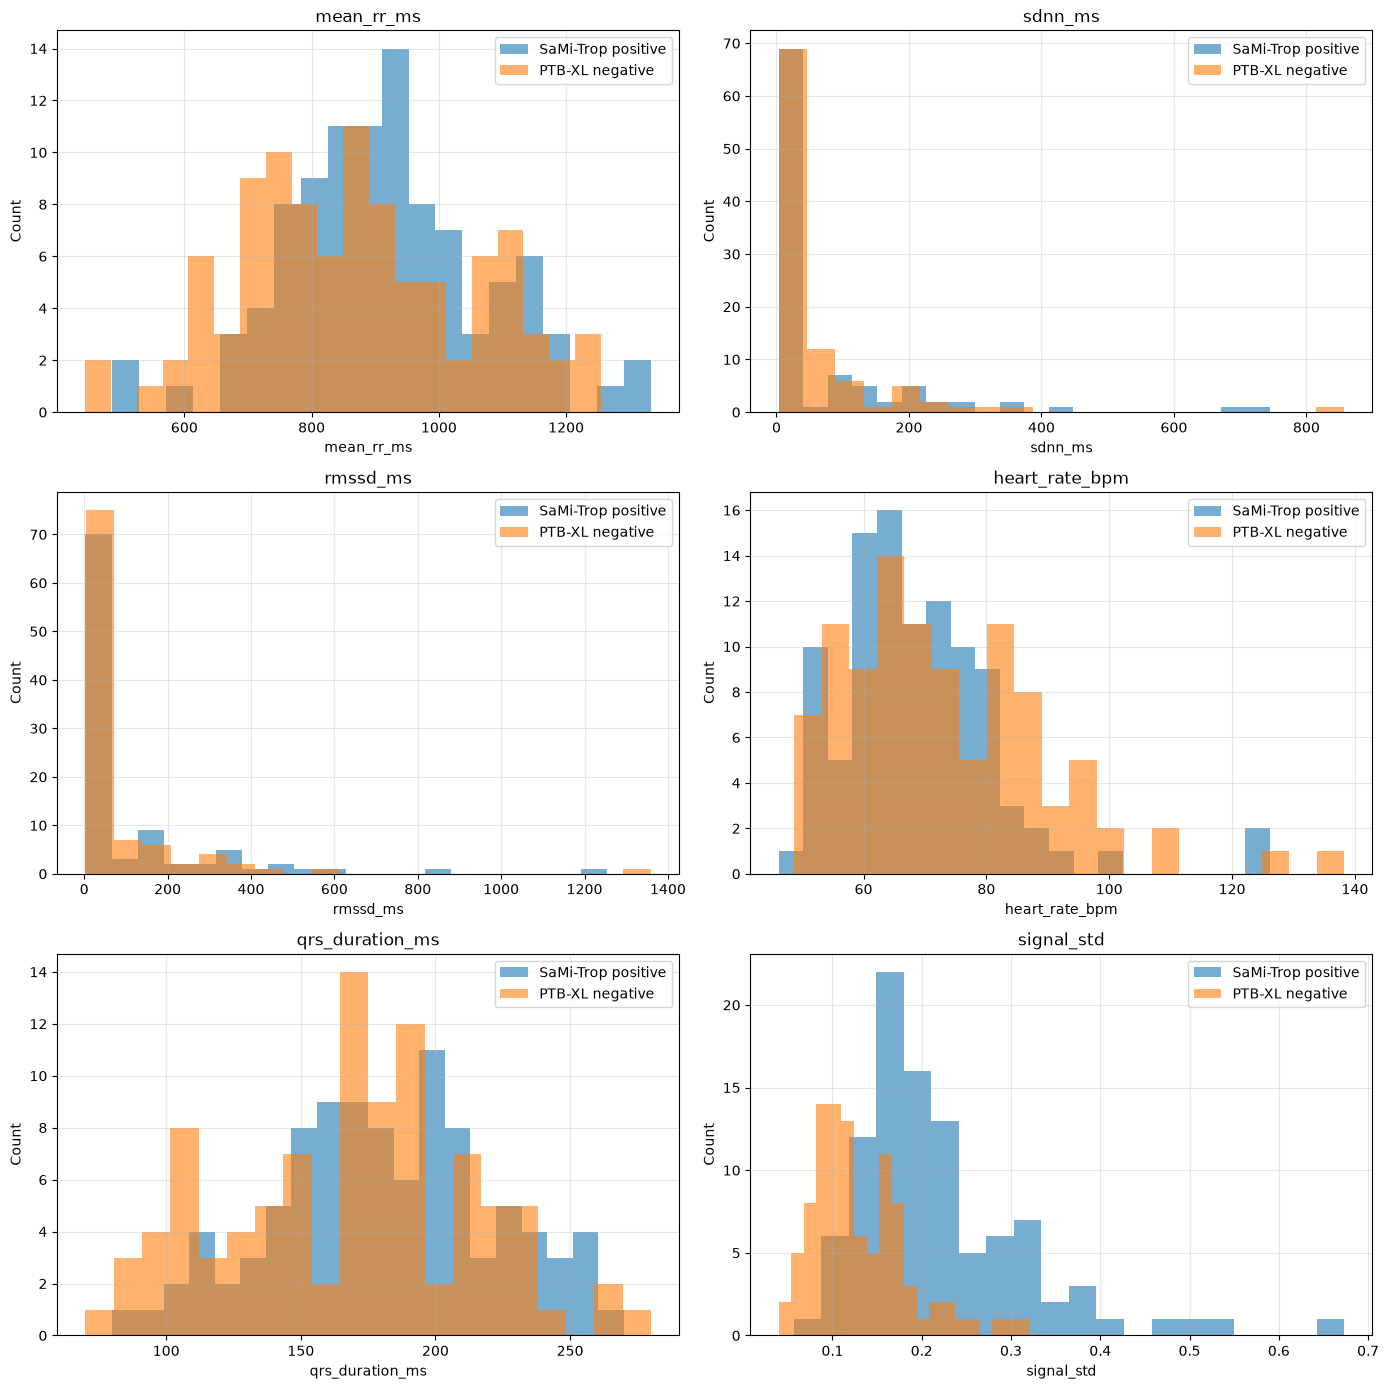

In [30]:
features_to_plot = [
    "mean_rr_ms",
    "sdnn_ms",
    "rmssd_ms",
    "heart_rate_bpm",
    "qrs_duration_ms",
    "signal_std"
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14)
)

axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):

    positive_values = feature_df[
        feature_df["label"] == 1
    ][feature].dropna()

    negative_values = feature_df[
        feature_df["label"] == 0
    ][feature].dropna()

    ax.hist(
        positive_values,
        bins=20,
        alpha=0.6,
        label="SaMi-Trop positive"
    )

    ax.hist(
        negative_values,
        bins=20,
        alpha=0.6,
        label="PTB-XL negative"
    )

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NOTE: 

Signal standard deviation looks like the most useful feature, followed by QRS duration. Mean RR, heart rate, SDNN, and RMSSD showed significant overlap between the groups and were less useful for separating the classes. SDNN and RMSSD were especially noisy because the ECG recordings were very short.